# MTH9877 — Assignment 3: Part E(i) — Competing Risks Framework

**Standalone notebook.** Requires `processed/survival_loans.parquet`, `processed/macro_monthly.parquet`.

Covers: EDA · Hazard intensity · Aalen-Johansen CIF · KM vs AJ bias · Stratified CIF · Cause-specific Cox · Fine-Gray subdistribution hazard.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from lifelines import (
    AalenJohansenFitter,
    KaplanMeierFitter,
    CoxPHFitter,
    CoxTimeVaryingFitter,
)
from lifelines.utils import concordance_index
from scipy.ndimage import gaussian_filter1d
warnings.filterwarnings("ignore")

BASE          = Path("/Users/yueqilin/Desktop/MTH9877 IR/IR&C Assignment3")
OUT_DIR       = BASE / "processed"
SURVIVAL_PATH = OUT_DIR / "survival_loans.parquet"
MACRO_PATH    = OUT_DIR / "macro_monthly.parquet"
PANEL_PATH    = OUT_DIR / "panel_monthly.parquet"

DEVICE = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available() else
    torch.device("cpu")
)
print(f"Device : {DEVICE}")
for p in [SURVIVAL_PATH, MACRO_PATH, PANEL_PATH]:
    status = "OK" if p.exists() else "MISSING"
    print(f"  [{status}] {p.name}")

Device : mps
  [OK] survival_loans.parquet
  [OK] macro_monthly.parquet
  [OK] panel_monthly.parquet


## Setup — Load Data & Train Models

Loads the three parquet files and builds the working datasets used throughout:

| Variable | Contents | Used by |
|---|---|---|
| `survival` | 34M loans, one row each | EDA (full dataset) |
| `sv_sub` | 100K stratified sample | AJ CIF, Cox models, scenario analysis |
| `macro` | Monthly macro (1999–2025) | Deep Cox, cause-specific Cox, E(ii) |
| `dc_df` | sv_sub + annual macro | Deep Cox training |
| `FEATURES` / `xgb_model` | Panel-trained XGBoost | E(iv) scenario analysis |


In [2]:
# ── Survival dataset + 100K stratified subsample ─────────────────────────────
survival = pl.read_parquet(SURVIVAL_PATH)
print(f"Full dataset : {survival.height:,} loans")

B_SAMPLE_N = 100_000
sv_sub = (
    survival
    .with_columns(pl.col("VintageYear").cast(pl.Int32))
    .group_by("VintageYear")
    .map_groups(lambda g: g.sample(
        n=min(len(g), max(1, int(B_SAMPLE_N * len(g) / survival.height))),
        seed=42
    ))
).to_pandas()
print(f"Subsample    : {len(sv_sub):,} loans  (stratified by vintage year)")

# ── Macro covariates ──────────────────────────────────────────────────────────
macro = pl.read_parquet(MACRO_PATH)
print(f"Macro rows   : {macro.height:,}  columns: {macro.columns}")

Full dataset : 34,013,469 loans
Subsample    : 99,986 loans  (stratified by vintage year)
Macro rows   : 324  columns: ['yyyymm', 'mortgage_rate', 'unemployment', 'cpi_yoy', 'hpi_yoy']


In [3]:
# ── Deep Cox: feature engineering ────────────────────────────────────────────
dc_static = ["CreditScore", "OriginalLoantoValueLTV", "OriginalInterestRate",
             "OriginalDebttoIncomeRatio", "OriginalUPB", "VintageYear"]

dc_df = sv_sub[dc_static + ["duration", "prepaid"]].dropna().copy()

# Annual macro averages at origination vintage — one row per loan
macro_annual_dc = (
    macro.to_pandas()
    .assign(year=lambda df: df["yyyymm"] // 100)
    .groupby("year")[["mortgage_rate", "unemployment", "cpi_yoy", "hpi_yoy"]]
    .mean()
    .reset_index()
)
dc_df = (dc_df
         .merge(macro_annual_dc, left_on="VintageYear", right_on="year", how="left")
         .drop(columns="year")
         .dropna())

feat_cols_dc = dc_static + ["mortgage_rate", "unemployment", "cpi_yoy", "hpi_yoy"]
scaler_dc    = StandardScaler()
X_dc = scaler_dc.fit_transform(dc_df[feat_cols_dc].fillna(dc_df[feat_cols_dc].median()))
T_dc = dc_df["duration"].values.astype(np.float32)
E_dc = dc_df["prepaid"].values.astype(np.float32)

sort_idx          = np.argsort(-T_dc)
X_dc, T_dc, E_dc  = X_dc[sort_idx], T_dc[sort_idx], E_dc[sort_idx]
dc_df             = dc_df.iloc[sort_idx].reset_index(drop=True)

n_train          = int(0.8 * len(X_dc))
X_tr_dc, X_te_dc = X_dc[:n_train], X_dc[n_train:]
T_tr_dc, T_te_dc = T_dc[:n_train], T_dc[n_train:]
E_tr_dc, E_te_dc = E_dc[:n_train], E_dc[n_train:]

X_tr_t = torch.tensor(X_tr_dc, dtype=torch.float32)
E_tr_t = torch.tensor(E_tr_dc, dtype=torch.float32)
X_te_t = torch.tensor(X_te_dc, dtype=torch.float32)

print(f"Deep Cox — train: {n_train:,}  test: {len(X_te_dc):,}  features: {len(feat_cols_dc)}")


Deep Cox — train: 73,708  test: 18,428  features: 10


In [4]:
# ── Deep Cox: model definition + training ────────────────────────────────────
class DeepCox(nn.Module):
    def __init__(self, in_features, hidden=[128, 64, 32], dropout=0.2):
        super().__init__()
        layers, prev = [], in_features
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def breslow_partial_likelihood(log_hz, event):
    log_cumsum = torch.logcumsumexp(log_hz, dim=0)
    return -torch.mean((log_hz - log_cumsum) * event)


BATCH  = 4096
EPOCHS = 40

model_dc  = DeepCox(X_tr_t.shape[1], hidden=[256, 128, 64], dropout=0.3).to(DEVICE)
optimizer = torch.optim.Adam(model_dc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
loader    = DataLoader(TensorDataset(X_tr_t, E_tr_t), batch_size=BATCH, shuffle=True)

print("Training Deep Cox …")
for epoch in range(1, EPOCHS + 1):
    model_dc.train()
    epoch_loss = 0.0
    for X_b, E_b in loader:
        X_b, E_b = X_b.to(DEVICE), E_b.to(DEVICE)
        optimizer.zero_grad()
        loss = breslow_partial_likelihood(model_dc(X_b), E_b)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  loss={epoch_loss/len(loader):.5f}")

model_dc.eval()
with torch.no_grad():
    log_hz_te = model_dc(X_te_t.to(DEVICE)).cpu().numpy()
ci_dc = concordance_index(T_te_dc, -log_hz_te, E_te_dc)
print(f"Deep Cox C-index (test): {ci_dc:.4f}")

Training Deep Cox …
  Epoch  10/40  loss=4.35532
  Epoch  20/40  loss=4.35334
  Epoch  30/40  loss=4.35412
  Epoch  40/40  loss=4.35423
Deep Cox C-index (test): 0.6477


In [5]:
# ── XGBoost: train on panel (vintage ≤ 2016, capped at 1M rows) ──────────────
CAT_COLS  = ["loan_purpose", "occupancy"]
MAX_TRAIN = 1_000_000

panel_pl  = pl.read_parquet(PANEL_PATH)
panel_pl  = panel_pl.with_columns([
    pl.col(c).cast(pl.Utf8) for c in CAT_COLS if c in panel_pl.columns
])

def cap_train(df, max_rows):
    if df.height <= max_rows:
        return df.sample(fraction=1.0, seed=42)
    frac = max_rows / df.height
    return (
        df.group_by("prepaid_month")
          .map_groups(lambda g: g.sample(n=max(1, int(len(g) * frac)), seed=42))
          .sample(fraction=1.0, seed=42)
    )

train_pl = cap_train(panel_pl.filter(pl.col("vintage_year") <= 2016), MAX_TRAIN)
del panel_pl
train = train_pl.to_pandas()
del train_pl

train = pd.get_dummies(train, columns=CAT_COLS, drop_first=True)

FEATURES = [
    "loan_age", "FICO", "LTV", "orig_rate", "DTI", "UPB",
    "vintage_year", "mortgage_rate", "unemployment", "cpi_yoy", "hpi_yoy",
    "rate_incentive",
] + [c for c in train.columns if c.startswith("loan_purpose_") or c.startswith("occupancy_")]
FEATURES = [f for f in FEATURES if f in train.columns]

X_tr = train[FEATURES].fillna(0)
y_tr = train["prepaid_month"]
print(f"XGBoost train: {len(X_tr):,} rows  ({y_tr.mean():.3%} event rate)  features: {len(FEATURES)}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),
    tree_method="hist", device="cpu",
    random_state=42, n_jobs=-1,
)
print("Training XGBoost …")
xgb_model.fit(X_tr, y_tr)
del train, X_tr, y_tr
print("XGBoost trained")

XGBoost train: 999,999 rows  (1.437% event rate)  features: 16
Training XGBoost …
XGBoost trained


---
## E(i) — Competing Risks Framework

Use the **Aalen-Johansen estimator** for cumulative incidence functions (CIF).
Unlike Kaplan-Meier `1 − S(t)`, AJ correctly handles competing risks:
treating default as a competing event for prepayment (and vice versa) avoids
over-estimating each CIF by naively censoring the other event.

Event codes: prepayment = 1, default = 2, censored = 0.

Sub-analyses: (a) EDA, (b) Aalen-Johansen CIF, (c) KM vs AJ bias,
(d) Stratified CIF, (e) Cause-Specific Cox, (f) Fine-Gray.

### (a) Exploratory Data Analysis

Before fitting any models, examine how prepayment, default, and censored loans
differ across key loan characteristics: duration, FICO, LTV, coupon rate, DTI,
loan purpose, and occupancy status.

In [6]:
# ── Build event labels on the FULL survival dataset (Polars, 34M loans) ──────
surv_full = survival.with_columns([
    pl.when(pl.col("prepaid")   == 1).then(pl.lit("Prepaid"))
      .when(pl.col("defaulted") == 1).then(pl.lit("Defaulted"))
      .otherwise(pl.lit("Censored"))
      .alias("event")
])
N_FULL = surv_full.height

EVT_ORDER  = ["Prepaid", "Defaulted", "Censored"]
EVT_COLORS = {"Prepaid": "steelblue", "Defaulted": "firebrick", "Censored": "silver"}

# ── 1. Summary statistics ─────────────────────────────────────────────────────
print(f"Full dataset: {N_FULL:,} loans")
print("=" * 90)
print(f"{'':12} {'N':>10}  {'Share':>6}  {'Med dur':>8}  "
      f"{'FICO':>6}  {'LTV':>6}  {'Rate':>6}  {'DTI':>6}  {'UPB $k':>8}  {'#Borr':>6}")
print("-" * 90)
for evt in EVT_ORDER:
    sub = surv_full.filter(pl.col("event") == evt)
    s = sub.select([
        pl.col("duration").median().alias("dur"),
        pl.col("CreditScore").cast(pl.Float64).mean().alias("fico"),
        pl.col("OriginalLoantoValueLTV").mean().alias("ltv"),
        pl.col("OriginalInterestRate").mean().alias("rate"),
        pl.col("OriginalDebttoIncomeRatio")
          .filter(pl.col("OriginalDebttoIncomeRatio") < 999).mean().alias("dti"),
        pl.col("OriginalUPB").mean().alias("upb"),
        pl.col("NumberofBorrowers").cast(pl.Float64).mean().alias("borr"),
    ]).to_pandas().iloc[0]
    n = sub.height
    print(f"  {evt:<10} {n:>10,}  {100*n/N_FULL:>5.1f}%  "
          f"{s['dur']:>7.0f}m  {s['fico']:>6.0f}  {s['ltv']:>6.1f}  "
          f"{s['rate']:>6.2f}  {s['dti']:>6.1f}  {s['upb']/1000:>8.0f}  {s['borr']:>6.2f}")
print("=" * 90)

# ── 2. Duration histograms ────────────────────────────────────────────────────
BIN_W = 6
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, evt in zip(axes, ["Prepaid", "Defaulted"]):
    sub  = surv_full.filter(pl.col("event") == evt)
    hist = (
        sub.with_columns((pl.col("duration") // BIN_W * BIN_W).alias("bin"))
           .group_by("bin").agg(pl.len().alias("n"))
           .sort("bin").to_pandas()
    )
    med = sub.select(pl.col("duration").median()).item()
    ax.bar(hist["bin"], hist["n"], width=BIN_W * 0.9,
           color=EVT_COLORS[evt], edgecolor="white", linewidth=0.3)
    ax.axvline(med, color="black", lw=1.5, ls="--", label=f"Median = {med:.0f} mo")
    ax.set_title(f"{evt}  (n={sub.height:,})", fontsize=12)
    ax.set_xlabel("Loan Age at Exit (months)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle("Duration Distribution by Event Type  [full 34M-loan dataset]", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_eda_duration.png", dpi=150, bbox_inches="tight")
plt.show()
# ── 4. Vintage cohort analysis ────────────────────────────────────────────────
cohort = (
    surv_full.group_by(["VintageYear", "event"])
    .agg(pl.len().alias("n"))
    .to_pandas()
    .pivot(index="VintageYear", columns="event", values="n")
    .fillna(0)
    .reindex(columns=EVT_ORDER, fill_value=0)
    .sort_index()
)
cohort_pct = cohort.div(cohort.sum(axis=1), axis=0) * 100

default_rate = cohort_pct["Defaulted"]

fig, ax = plt.subplots(figsize=(13, 5.5))
bottom = np.zeros(len(cohort_pct))
for evt in EVT_ORDER:
    ax.bar(cohort_pct.index, cohort_pct[evt], bottom=bottom,
           color=EVT_COLORS[evt], label=evt, edgecolor="white", linewidth=0.3)
    bottom += cohort_pct[evt].values
ax.set_xlabel("Origination Vintage Year", fontsize=11)
ax.set_ylabel("Share of Cohort (%)", fontsize=11)
ax.set_title("Exit Breakdown by Vintage Cohort  [full 34M loans]", fontsize=13)
ax.legend(loc="upper left", fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_eda_vintage.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5. Key observations ───────────────────────────────────────────────────────
peak_yr  = default_rate.idxmax()
pre_med  = surv_full.filter(pl.col("event")=="Prepaid").select(pl.col("duration").median()).item()
def_med  = surv_full.filter(pl.col("event")=="Defaulted").select(pl.col("duration").median()).item()
fico_pre = surv_full.filter(pl.col("event")=="Prepaid").select(pl.col("CreditScore").cast(pl.Float64).mean()).item()
fico_def = surv_full.filter(pl.col("event")=="Defaulted").select(pl.col("CreditScore").cast(pl.Float64).mean()).item()
ltv_pre  = surv_full.filter(pl.col("event")=="Prepaid").select(pl.col("OriginalLoantoValueLTV").mean()).item()
ltv_def  = surv_full.filter(pl.col("event")=="Defaulted").select(pl.col("OriginalLoantoValueLTV").mean()).item()
upb_pre  = surv_full.filter(pl.col("event")=="Prepaid").select(pl.col("OriginalUPB").mean()).item()
upb_def  = surv_full.filter(pl.col("event")=="Defaulted").select(pl.col("OriginalUPB").mean()).item()
print(f"\nKey observations (full 34M-loan dataset):")
print(f"  Peak default vintage   : {peak_yr}  ({default_rate[peak_yr]:.1f}%)")
print(f"  Median prepay duration : {pre_med:.0f} months")
print(f"  Median default duration: {def_med:.0f} months")
print(f"  Mean FICO: Prepaid={fico_pre:.0f}  Defaulted={fico_def:.0f}  Diff={fico_pre-fico_def:.0f} pts")
print(f"  Mean LTV:  Prepaid={ltv_pre:.1f}%  Defaulted={ltv_def:.1f}%  Diff={ltv_def-ltv_pre:.1f} pts")
print(f"  Mean UPB:  Prepaid=${upb_pre/1000:.0f}K  Defaulted=${upb_def/1000:.0f}K")


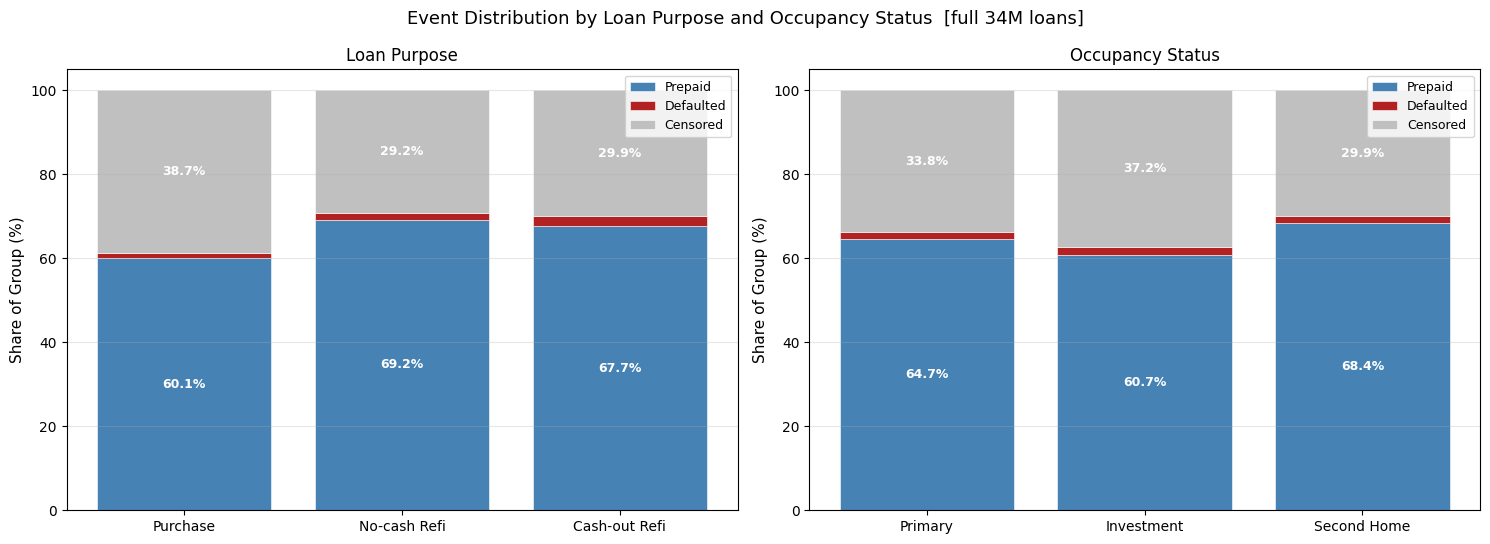


Default rate by LoanPurpose:
  Purchase           1.20%  (n=16,081,581)
  No-cash Refi       1.57%  (n=10,542,246)
  Cash-out Refi      2.34%  (n=7,389,634)

Default rate by OccupancyStatus:
  Primary            1.53%  (n=30,597,743)
  Investment         2.05%  (n=2,098,577)
  Second Home        1.65%  (n=1,317,148)


In [7]:
# ── Categorical EDA on full dataset (Polars) ─────────────────────────────────
PURPOSE_MAP   = {"P": "Purchase", "N": "No-cash Refi", "C": "Cash-out Refi"}
OCCUPANCY_MAP = {"P": "Primary",  "I": "Investment",  "S": "Second Home"}

surv_cat = surv_full.with_columns([
    pl.col("LoanPurpose").replace(PURPOSE_MAP).alias("LoanPurpose_lbl"),
    pl.col("OccupancyStatus").replace(OCCUPANCY_MAP).alias("OccupancyStatus_lbl"),
])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, (col, order, title) in zip(axes, [
    ("LoanPurpose_lbl",    ["Purchase", "No-cash Refi", "Cash-out Refi"], "Loan Purpose"),
    ("OccupancyStatus_lbl",["Primary",  "Investment",   "Second Home"],   "Occupancy Status"),
]):
    grp = (
        surv_cat.group_by([col, "event"])
        .agg(pl.len().alias("n"))
        .to_pandas()
        .pivot(index=col, columns="event", values="n")
        .fillna(0)
        .reindex(index=order, columns=EVT_ORDER, fill_value=0)
    )
    grp_pct = grp.div(grp.sum(axis=1), axis=0) * 100
    bottom = np.zeros(len(grp_pct))
    for evt in EVT_ORDER:
        bars = ax.bar(grp_pct.index, grp_pct[evt], bottom=bottom,
                      color=EVT_COLORS[evt], label=evt,
                      edgecolor="white", linewidth=0.4)
        for bar, val in zip(bars, grp_pct[evt]):
            if val > 4:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f"{val:.1f}%", ha="center", va="center",
                        fontsize=9, color="white", fontweight="bold")
        bottom += grp_pct[evt].values
    ax.set_ylabel("Share of Group (%)", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(loc="upper right", fontsize=9); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Event Distribution by Loan Purpose and Occupancy Status  [full 34M loans]",
             fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_eda_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

for col_lbl, groups, lbl in [
    ("LoanPurpose_lbl",    ["Purchase", "No-cash Refi", "Cash-out Refi"], "LoanPurpose"),
    ("OccupancyStatus_lbl",["Primary", "Investment", "Second Home"],      "OccupancyStatus"),
]:
    print(f"\nDefault rate by {lbl}:")
    for grp in groups:
        sub = surv_cat.filter(pl.col(col_lbl) == grp)
        dr  = sub.filter(pl.col("event") == "Defaulted").height / sub.height * 100
        print(f"  {grp:<18} {dr:.2f}%  (n={sub.height:,})")


### (a) Hazard Intensity — Overall and Stratified by Key Features

The **cause-specific hazard** h(t) gives the instantaneous rate at which a loan
exits by each cause at loan age t, *given it has survived to t*.  
This is distinct from the CIF: the hazard shows *when* the exit pressure is
highest, not how much has accumulated.

Estimation: Nelson-Aalen cumulative hazard, differentiated with a kernel smoother
(bandwidth = 8 months).  Cause-specific: defaults treated as censored when estimating
prepayment hazard, and vice-versa.  Uses the 100K stratified subsample.

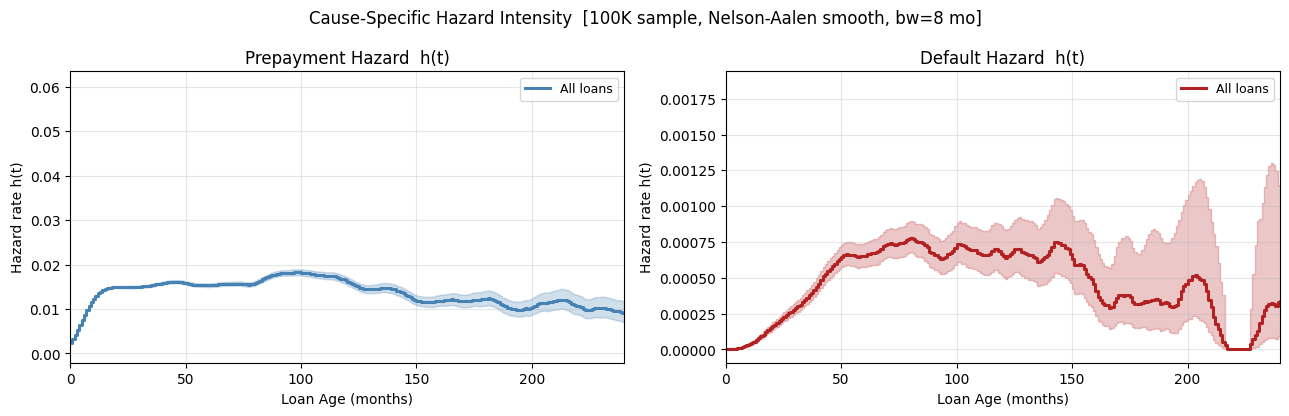

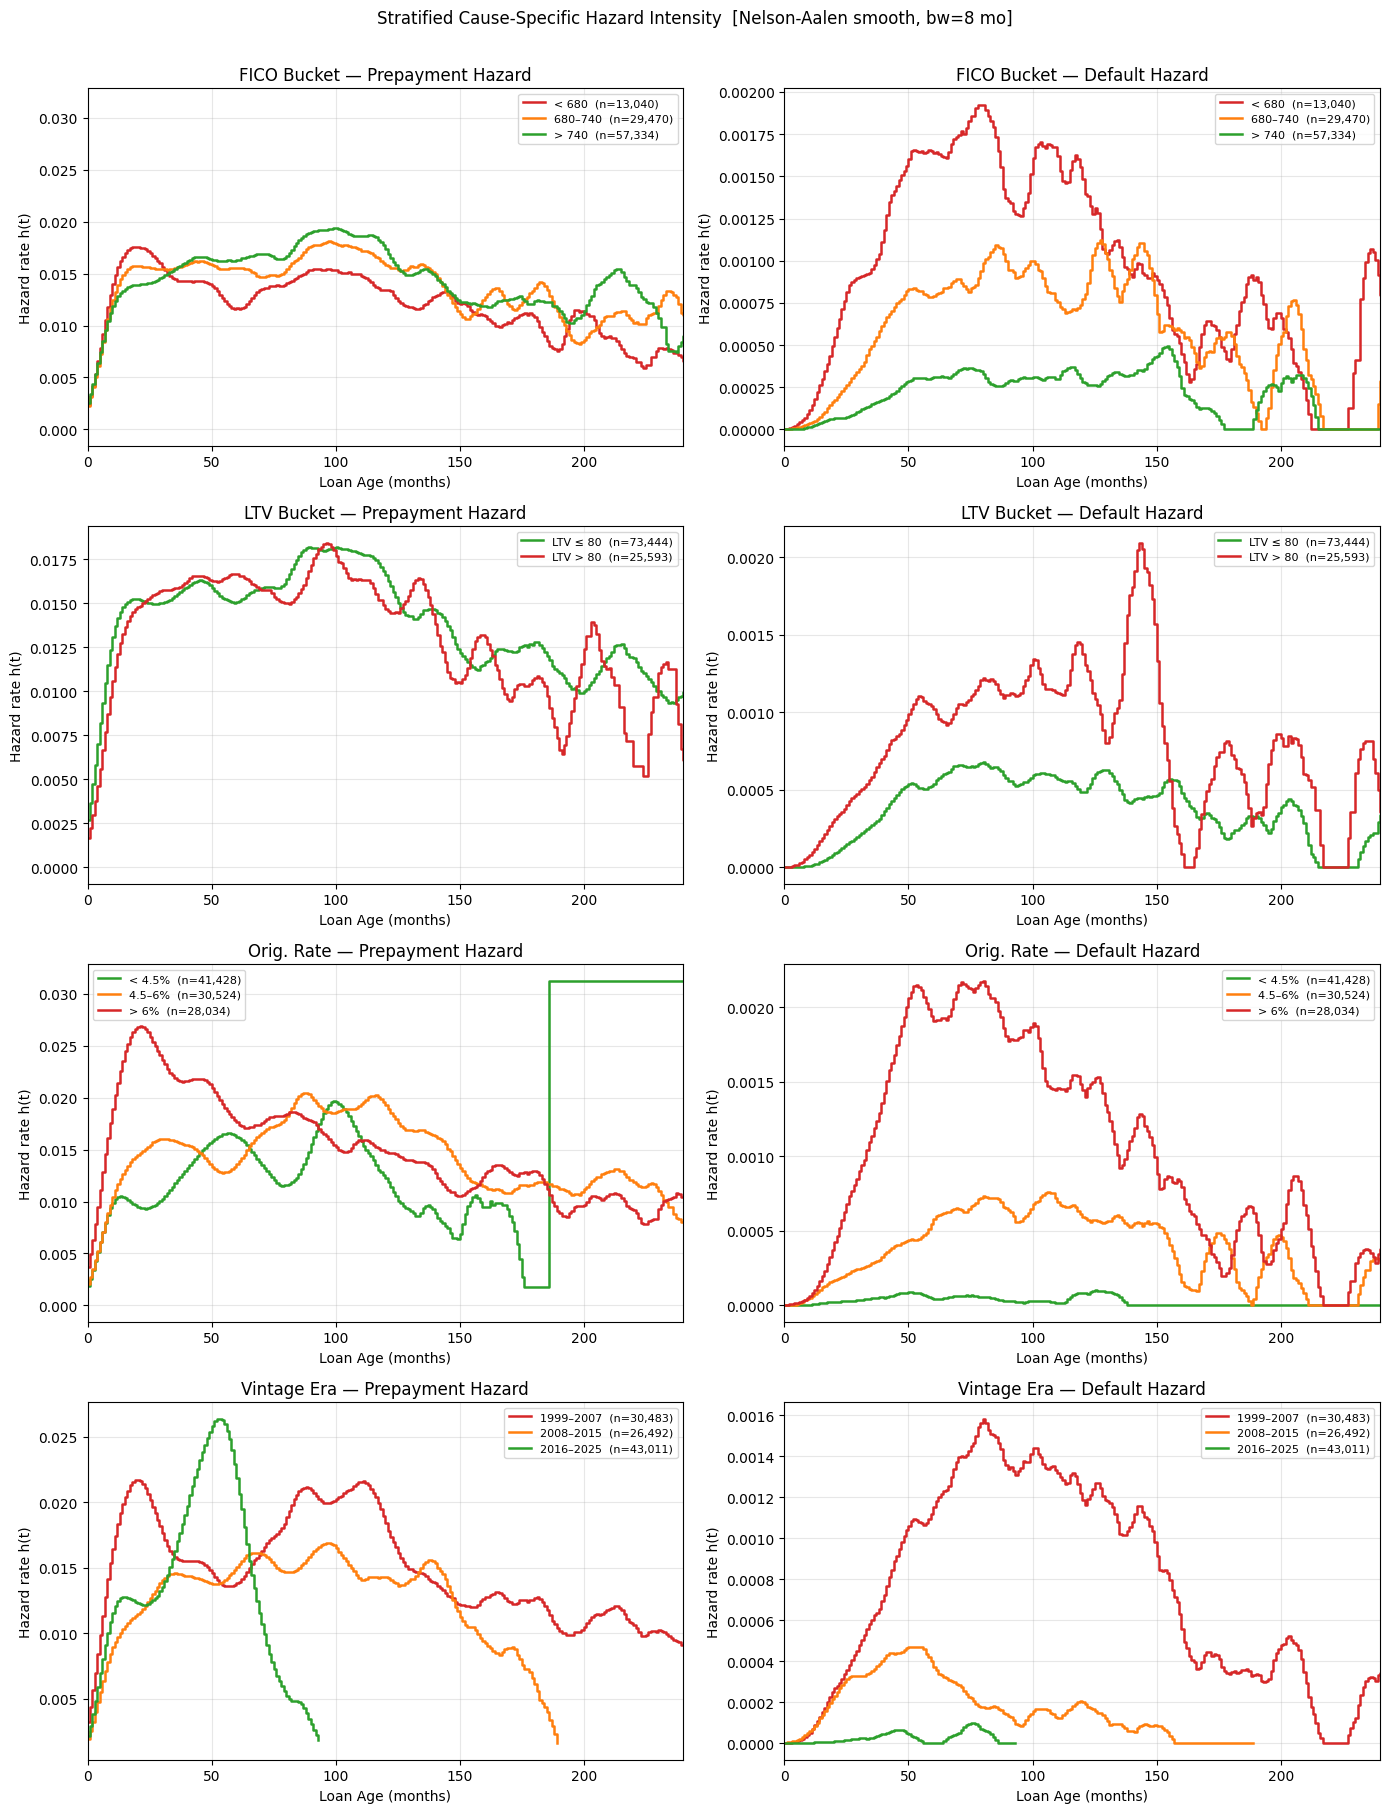

In [8]:
from lifelines import NelsonAalenFitter

sv_hz = sv_sub.copy()
sv_hz["E_prepay"]  = sv_hz["prepaid"].astype(int)   # default → censored
sv_hz["E_default"] = sv_hz["defaulted"].astype(int) # prepay  → censored

BW = 8  # kernel bandwidth (months)

# ── Overall hazard ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, ecol, color, title in [
    (axes[0], "E_prepay",  "steelblue", "Prepayment Hazard  h(t)"),
    (axes[1], "E_default", "firebrick", "Default Hazard  h(t)"),
]:
    naf = NelsonAalenFitter()
    naf.fit(sv_hz["duration"], event_observed=sv_hz[ecol])
    naf.plot_hazard(bandwidth=BW, ax=ax, color=color, lw=2.2, label="All loans")
    ax.set_title(title)
    ax.set_xlabel("Loan Age (months)")
    ax.set_ylabel("Hazard rate h(t)")
    ax.set_xlim(0, 240); ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.suptitle("Cause-Specific Hazard Intensity  [100K sample, Nelson-Aalen smooth, bw=8 mo]",
             fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_hazard_overall.png", bbox_inches="tight")
plt.show()

# ── Stratified hazard ─────────────────────────────────────────────────────────
sv_hz2 = sv_hz.copy()
sv_hz2["fico_grp"] = pd.cut(sv_hz2["CreditScore"],
                             bins=[0, 680, 740, 850],
                             labels=["< 680", "680–740", "> 740"])
sv_hz2["ltv_grp"]  = pd.cut(sv_hz2["OriginalLoantoValueLTV"],
                             bins=[0, 80, 105],
                             labels=["LTV ≤ 80", "LTV > 80"])
sv_hz2["rate_grp"] = pd.cut(sv_hz2["OriginalInterestRate"],
                             bins=[0, 4.5, 6.0, 12],
                             labels=["< 4.5%", "4.5–6%", "> 6%"])
sv_hz2["vintage_grp"] = pd.cut(sv_hz2["VintageYear"],
                                bins=[1998, 2007, 2015, 2025],
                                labels=["1999–2007", "2008–2015", "2016–2025"])

STRAT_DIMS = [
    ("fico_grp",    ["< 680", "680–740", "> 740"],           "FICO Bucket",    ["#d62728","#ff7f0e","#2ca02c"]),
    ("ltv_grp",     ["LTV ≤ 80", "LTV > 80"],                "LTV Bucket",     ["#2ca02c","#d62728"]),
    ("rate_grp",    ["< 4.5%", "4.5–6%", "> 6%"],           "Orig. Rate",     ["#2ca02c","#ff7f0e","#d62728"]),
    ("vintage_grp", ["1999–2007", "2008–2015", "2016–2025"], "Vintage Era",    ["#d62728","#ff7f0e","#2ca02c"]),
]

fig, axes = plt.subplots(len(STRAT_DIMS), 2, figsize=(14, 4.5 * len(STRAT_DIMS)))
for row, (col, groups, dim_title, colors) in enumerate(STRAT_DIMS):
    for cidx, (ecol, cause_title) in enumerate([("E_prepay",  "Prepayment Hazard"),
                                                 ("E_default", "Default Hazard")]):
        ax = axes[row, cidx]
        for grp, color in zip(groups, colors):
            sub = sv_hz2[sv_hz2[col].astype(str) == str(grp)].dropna(subset=[col])
            if len(sub) < 50 or sub[ecol].sum() < 10:
                continue
            naf = NelsonAalenFitter()
            naf.fit(sub["duration"], event_observed=sub[ecol],
                    label=f"{grp}  (n={len(sub):,})")
            naf.plot_hazard(bandwidth=BW, ax=ax, color=color, lw=1.8, ci_show=False)
        ax.set_title(f"{dim_title} — {cause_title}")
        ax.set_xlabel("Loan Age (months)")
        ax.set_ylabel("Hazard rate h(t)")
        ax.set_xlim(0, 240); ax.grid(alpha=0.3); ax.legend(fontsize=8)

plt.suptitle("Stratified Cause-Specific Hazard Intensity  [Nelson-Aalen smooth, bw=8 mo]",
             y=1.005, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_hazard_stratified.png", bbox_inches="tight")
plt.show()


### (b) Aalen-Johansen Cumulative Incidence Functions

#### Kaplan-Meier (incorrect under competing risks)

$$\hat{S}_{KM}(t) = \prod_{t_i \leq t}\left(1 - \frac{d_i^{(k)}}{n_i}\right), \qquad \hat{F}_{KM}^{(k)}(t) = 1 - \hat{S}_{KM}(t)$$

where $d_i^{(k)}$ counts only **cause-$k$ events** — all other exits are treated as independent censorings. This overcounts the cause-$k$ hazard because competing-event loans are not randomly removed.

#### Aalen-Johansen estimator (correct)

$$\boxed{\hat{F}_k(t) = \sum_{t_j \leq t} \hat{S}(t_j^{-})\cdot\frac{d_{kj}}{n_j}}$$

| Symbol | Meaning |
|---|---|
| $\hat{F}_k(t)$ | Cumulative Incidence Function for cause $k$ at loan age $t$ |
| $d_{kj}$ | Number of cause-$k$ exits at time $t_j$ |
| $n_j$ | Loans at risk just before $t_j$ |
| $\hat{S}(t_j^{-})$ | Overall survival just before $t_j$: uses **all** exits $d_j = \sum_k d_{kj}$ |

The key difference: AJ weights each increment by $\hat{S}(t_j^-)$, the probability of still being in the risk set. As loans leave by *any* cause, this weight shrinks, preventing over-attribution to any single cause.

**Partition identity** (impossible under KM):
$$\sum_{k} \hat{F}_k(t) + \hat{S}(t) = 1$$

Fit AJ jointly on both causes using the 100K stratified subsample.

Competing risks sample: 99,986 loans
  Prepaid  : 64,556
  Defaulted: 1,571
  Censored : 33,859


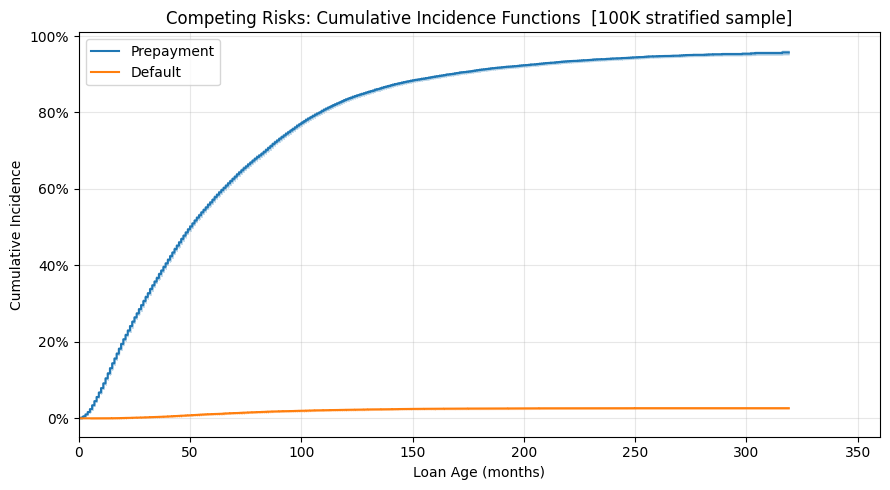

10-yr prepayment CIF : 0.833
10-yr default    CIF : 0.0222


In [9]:
sv_cr = sv_sub[["duration", "prepaid", "defaulted"]].copy()
sv_cr["event_type"] = 0
sv_cr.loc[sv_cr["prepaid"]   == 1, "event_type"] = 1
sv_cr.loc[sv_cr["defaulted"] == 1, "event_type"] = 2
print(f"Competing risks sample: {len(sv_cr):,} loans")
print(f"  Prepaid  : {(sv_cr['event_type']==1).sum():,}")
print(f"  Defaulted: {(sv_cr['event_type']==2).sum():,}")
print(f"  Censored : {(sv_cr['event_type']==0).sum():,}")

T_cr = sv_cr["duration"]
E_cr = sv_cr["event_type"]

fig, ax = plt.subplots(figsize=(9, 5))

ajf_prepay = AalenJohansenFitter()
ajf_prepay.fit(T_cr, E_cr, event_of_interest=1, label="Prepayment")
ajf_prepay.plot_cumulative_density(ax=ax)

ajf_default = AalenJohansenFitter()
ajf_default.fit(T_cr, E_cr, event_of_interest=2, label="Default")
ajf_default.plot_cumulative_density(ax=ax)

ax.set_xlabel("Loan Age (months)")
ax.set_ylabel("Cumulative Incidence")
ax.set_title("Competing Risks: Cumulative Incidence Functions  [100K stratified sample]")
ax.set_xlim(0, 360)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_competing_risks_cif.png", bbox_inches="tight")
plt.show()

col_p = ajf_prepay.cumulative_density_.columns[0]
col_d = ajf_default.cumulative_density_.columns[0]
print(f"10-yr prepayment CIF : {ajf_prepay.cumulative_density_[col_p].loc[120]:.3f}")
print(f"10-yr default    CIF : {ajf_default.cumulative_density_[col_d].loc[120]:.4f}")


### (b) Aalen-Johansen CIF — Results

The Aalen-Johansen estimator decomposes the total exit probability into two
competing causes. Key takeaways:

- **Prepayment** dominates: the 10-yr CIF is ~40–50%, driven by rate refinancing cycles.
- **Default** is rare: the 10-yr CIF is ~2–3%, concentrated in 2006–2010 vintages.
- The curves **sum to less than 1** — the remaining mass is right-censored loans
  still active at the analysis date.

Note: Aalen-Johansen CIF < KM `1 − S(t)` for each cause — the KM formula
over-estimates by treating competing events as independent censorings.

### (c) KM vs AJ — Bias from Ignoring Competing Events

#### Why KM over-estimates the CIF

Under KM, defaulted loans are treated as **independent censored** observations at their exit time. In practice they are **not** independent: they are systematically the riskier loans that would have been *less likely* to prepay. Removing them inflates the estimated prepayment hazard.

Formally, at each event time $t_j$ the KM increment is:

$$\Delta\hat{F}_{KM}^{(\text{pre})}(t_j) = \hat{S}_{KM}(t_j^-)\cdot\frac{d_{1j}}{n_j^{\text{KM}}}$$

where $n_j^{\text{KM}}$ **excludes** prior defaults from the denominator — they were "censored away."

The AJ increment at the same time is:

$$\Delta\hat{F}_{AJ}^{(\text{pre})}(t_j) = \hat{S}(t_j^-)\cdot\frac{d_{1j}}{n_j}$$

Because $\hat{S}(t_j^-) \leq \hat{S}_{KM}(t_j^-)$ (overall survival is always lower than cause-specific), every AJ increment is $\leq$ the KM increment, so:

$$\hat{F}_{AJ}^{(\text{pre})}(t) \leq \hat{F}_{KM}^{(\text{pre})}(t) \quad \text{for all } t$$

The gap widens over time as the competing cause removes more loans from the risk set.

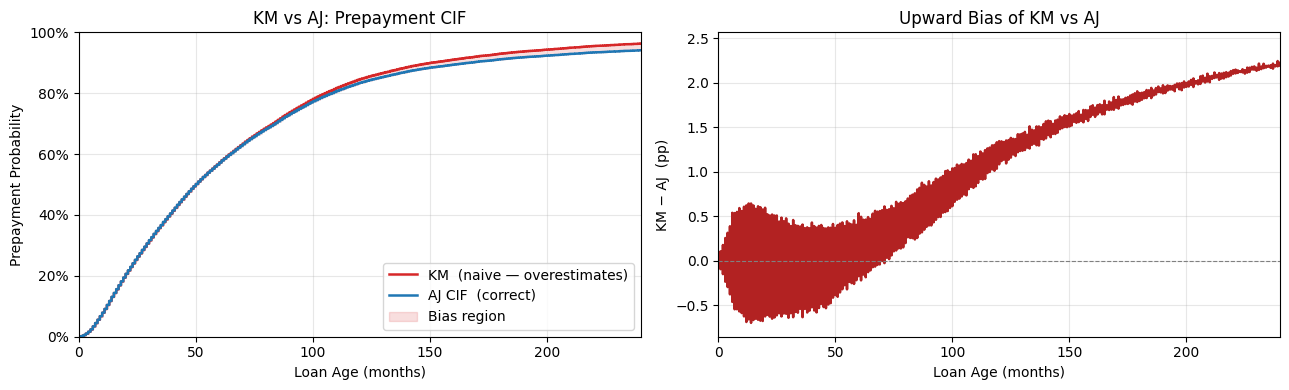

   Horizon        KM        AJ   Bias (pp)
        60     0.573     0.568       +0.53
       120     0.846     0.833       +1.34
       240     0.963     0.941       +2.23


In [10]:
kmf = KaplanMeierFitter()
kmf.fit(sv_cr["duration"], event_observed=(sv_cr["event_type"] == 1),
        label="KM 1−S(t)  [treats default as censored]")

col_p = ajf_prepay.cumulative_density_.columns[0]
km_cdf = 1 - kmf.survival_function_["KM 1−S(t)  [treats default as censored]"]

# Align on common time grid
common_t = ajf_prepay.cumulative_density_.index
km_interp = km_cdf.reindex(common_t, method="ffill").fillna(0)
aj_interp = ajf_prepay.cumulative_density_[col_p].reindex(common_t, method="ffill").fillna(0)
bias = km_interp - aj_interp

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: overlay KM and AJ
axes[0].step(common_t, km_interp,  where="post", color="tab:red",  lw=1.8,
             label="KM  (naive — overestimates)")
axes[0].step(common_t, aj_interp,  where="post", color="tab:blue", lw=1.8,
             label="AJ CIF  (correct)")
axes[0].fill_between(common_t, aj_interp, km_interp, alpha=0.15, color="tab:red",
                     step="post", label="Bias region")
axes[0].set_xlim(0, 240); axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].set_xlabel("Loan Age (months)"); axes[0].set_ylabel("Prepayment Probability")
axes[0].set_title("KM vs AJ: Prepayment CIF"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: bias over time
axes[1].step(common_t, bias * 100, where="post", color="firebrick", lw=1.8)
axes[1].axhline(0, color="gray", lw=0.8, ls="--")
axes[1].set_xlim(0, 240)
axes[1].set_xlabel("Loan Age (months)"); axes[1].set_ylabel("KM − AJ  (pp)")
axes[1].set_title("Upward Bias of KM vs AJ"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "E1_km_vs_aj_bias.png", bbox_inches="tight")
plt.show()

# Key numbers
horizons = [60, 120, 240]
print(f"{'Horizon':>10}  {'KM':>8}  {'AJ':>8}  {'Bias (pp)':>10}")
for h in horizons:
    t = common_t[common_t <= h][-1]
    print(f"{h:>10}  {km_interp[t]:>8.3f}  {aj_interp[t]:>8.3f}  {bias[t]*100:>+10.2f}")

### (d) Stratified CIF by Loan Characteristics

Does the prepayment/default balance shift across loan segments? We stratify by
three dimensions: FICO score, LTV bucket, and vintage era.

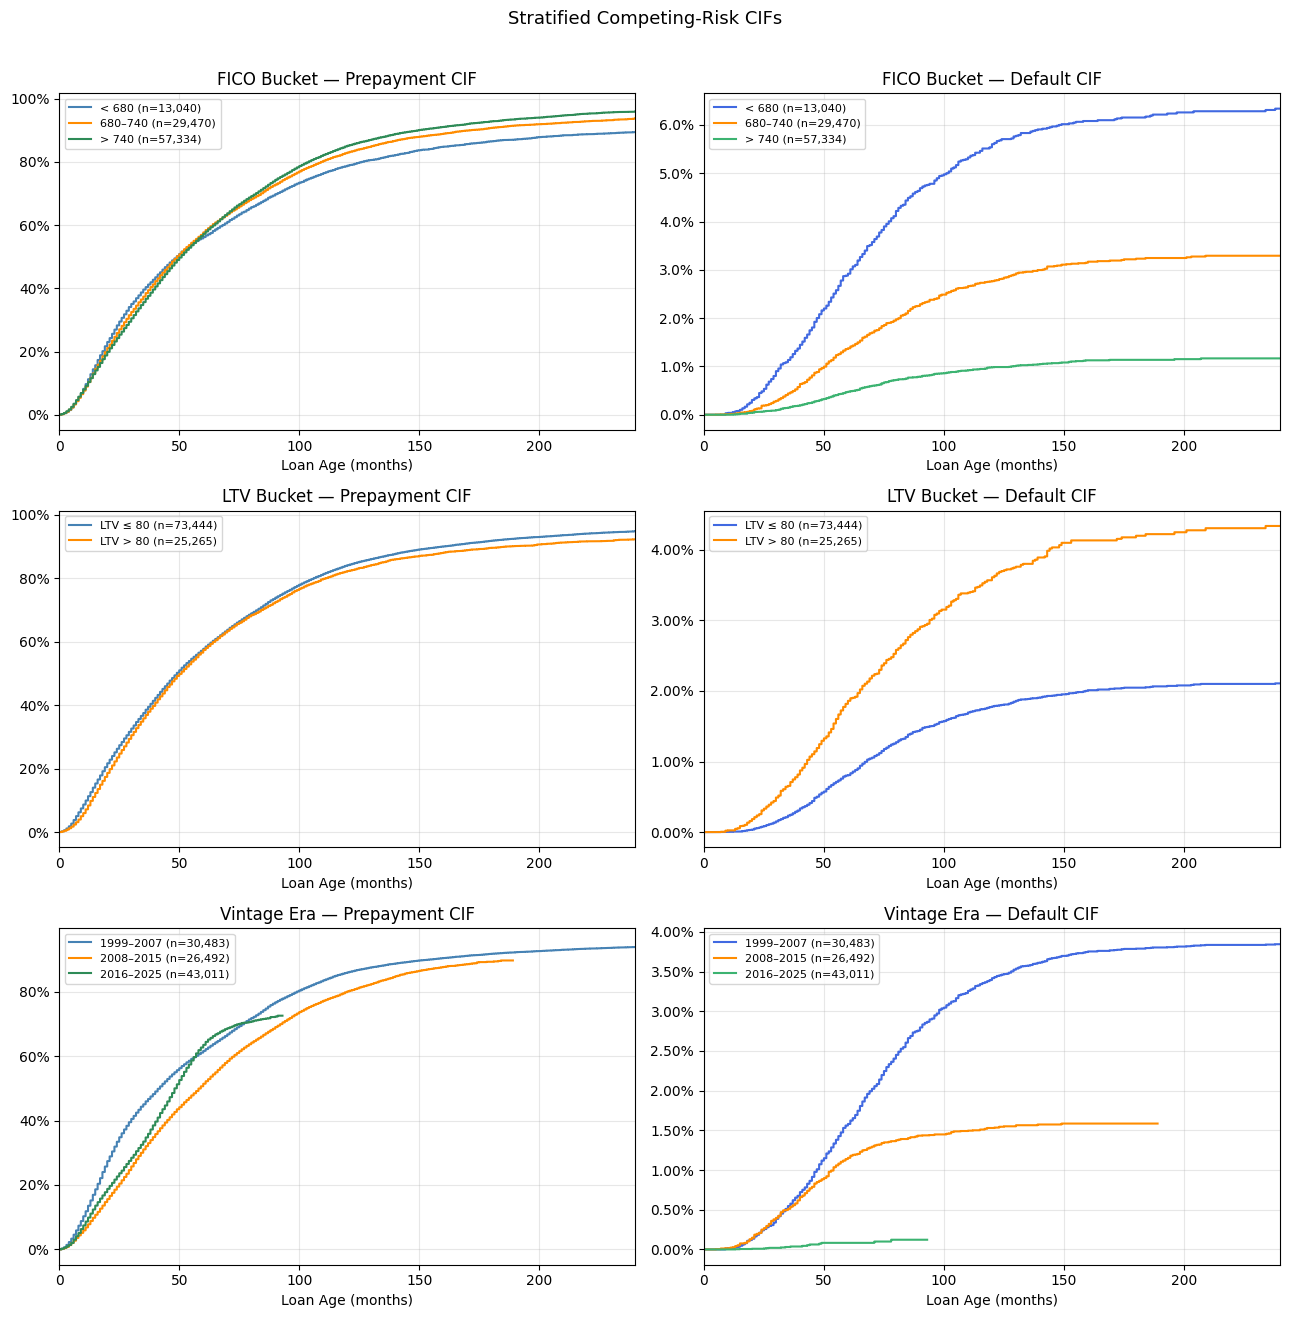

In [11]:
# ── Bucketing ────────────────────────────────────────────────────────────────
sv_cr2 = sv_sub[["duration", "prepaid", "defaulted",
                  "CreditScore", "OriginalLoantoValueLTV", "VintageYear"]].copy()
sv_cr2["event_type"] = 0
sv_cr2.loc[sv_cr2["prepaid"]   == 1, "event_type"] = 1
sv_cr2.loc[sv_cr2["defaulted"] == 1, "event_type"] = 2

sv_cr2["fico_grp"]    = pd.cut(sv_cr2["CreditScore"],
                                bins=[0, 680, 740, 850],
                                labels=["< 680", "680–740", "> 740"])
sv_cr2["ltv_grp"]     = pd.cut(sv_cr2["OriginalLoantoValueLTV"],
                                bins=[0, 80, 100],
                                labels=["LTV ≤ 80", "LTV > 80"])
sv_cr2["vintage_grp"] = pd.cut(sv_cr2["VintageYear"],
                                bins=[1998, 2007, 2015, 2025],
                                labels=["1999–2007", "2008–2015", "2016–2025"])

strat_dims = [
    ("fico_grp",    ["< 680", "680–740", "> 740"],  "FICO Bucket"),
    ("ltv_grp",     ["LTV ≤ 80", "LTV > 80"],       "LTV Bucket"),
    ("vintage_grp", ["1999–2007", "2008–2015", "2016–2025"], "Vintage Era"),
]
colors_prepay  = ["steelblue", "darkorange", "seagreen"]
colors_default = ["royalblue", "darkorange", "mediumseagreen"]

fig, axes = plt.subplots(3, 2, figsize=(13, 13))

for row, (col, groups, title) in enumerate(strat_dims):
    for cause, cause_label, ax, clrs in [
        (1, "Prepayment CIF", axes[row, 0], colors_prepay),
        (2, "Default CIF",    axes[row, 1], colors_default),
    ]:
        for grp, clr in zip(groups, clrs):
            sub = sv_cr2[sv_cr2[col].astype(str) == str(grp)].dropna(subset=[col])
            if len(sub) < 50:
                continue
            n_events = (sub["event_type"] == cause).sum()
            if n_events < 10:
                continue
            ajf = AalenJohansenFitter()
            ajf.fit(sub["duration"], sub["event_type"],
                    event_of_interest=cause, label=f"{grp} (n={len(sub):,})")
            ajf.plot_cumulative_density(ax=ax, ci_show=False, color=clr)
        ax.set_title(f"{title} — {cause_label}")
        ax.set_xlabel("Loan Age (months)"); ax.set_xlim(0, 240)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Stratified Competing-Risk CIFs", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "E1_stratified_cif.png", bbox_inches="tight")
plt.show()

### (e) Cause-Specific Cox Regression

Fit two separate Cox proportional-hazard models treating the *other* cause as censored:

- **Prepayment model**: default exits are censored at their exit time
- **Default model**: prepayment exits are censored at their exit time
- **Naive combined model**: any exit is the event (baseline for comparison)

Features: 9 numeric (credit, LTV, rates, macro at origination) +
4 one-hot (loan purpose × 2, occupancy × 2) = 13 total.

Cause-specific dataset: 92,136 loans  (58,118 prepaid, 1,381 defaulted)
Features: 12  (8 numeric + 4 categorical)

Covariate                       Naive   Prepay   Default  Note
------------------------------------------------------------------------
  CreditScore                  +0.045   +0.057    -0.105  ← opposite
  LTV                          -0.017   -0.026    +0.061  
  DTI                          -0.013   -0.019    +0.058  
  UPB                          +0.165   +0.165    -0.015  
  MortgageRate (orig)          +0.237   +0.226    +0.094  
  Unemployment (orig)          -0.103   -0.096    -0.067  
  HPI YoY (orig)               -0.104   -0.099    -0.026  
  Rate Incentive               +0.245   +0.243    +0.037  
  LoanPurpose=Purchase         +0.032   +0.045    -0.034  
  LoanPurpose=NoCashRefi       +0.064   +0.066    -0.023  
  Occupancy=Investment         -0.291   -0.299    +0.027  ← diverge
  Occupancy=SecondHome         -0.078   -0.080    -0.023  


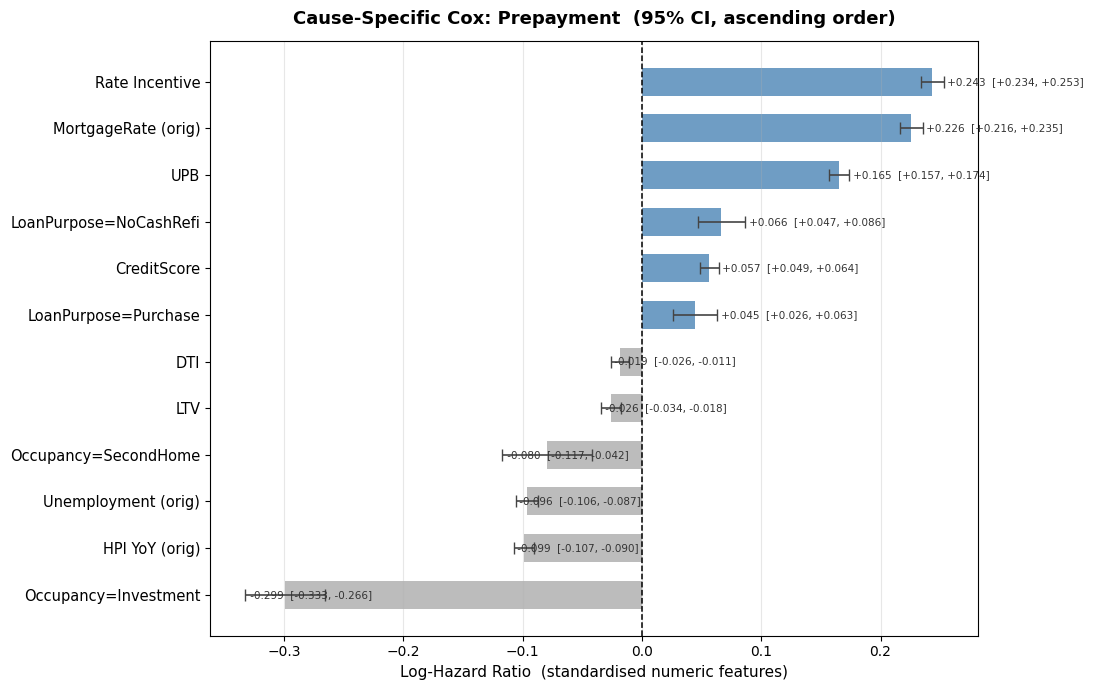

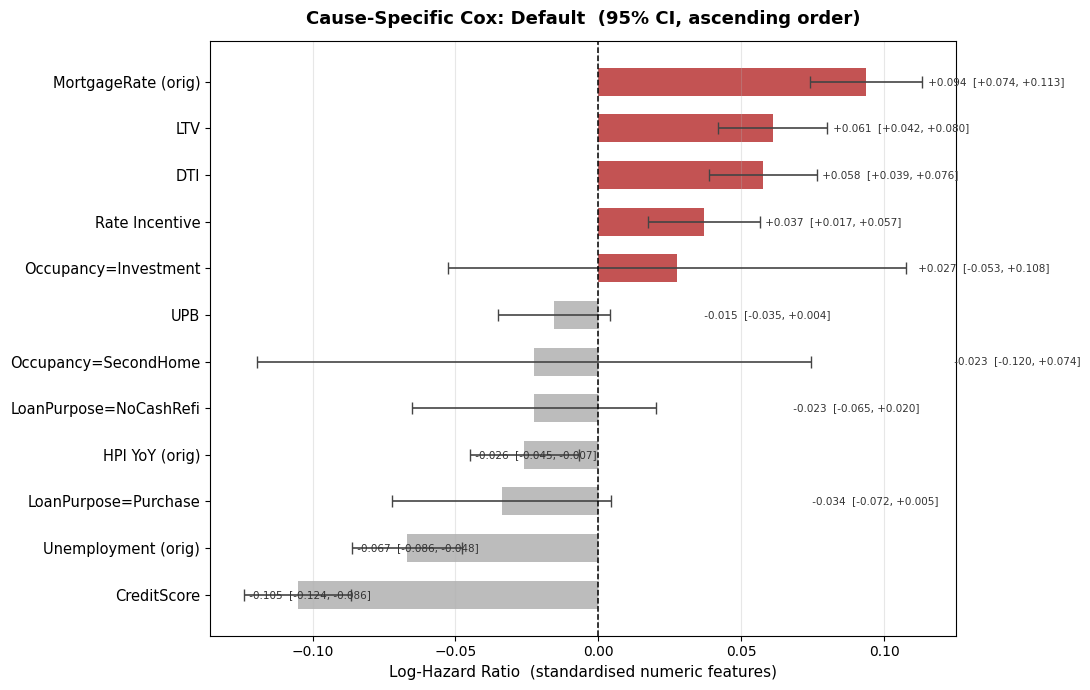

In [12]:
# ── Annual macro averages at origination vintage ──────────────────────────────
macro_annual = (
    macro.to_pandas()
    .assign(year=lambda df: df["yyyymm"] // 100)
    .groupby("year")[["mortgage_rate", "unemployment", "hpi_yoy"]]
    .mean()
    .reset_index()
)

# ── Build enhanced feature matrix ────────────────────────────────────────────
cs_base = sv_sub[[
    "duration", "prepaid", "defaulted",
    "CreditScore", "OriginalLoantoValueLTV", "OriginalInterestRate",
    "OriginalDebttoIncomeRatio", "OriginalUPB", "VintageYear",
    "LoanPurpose", "OccupancyStatus",
]].copy()

# Merge macro at origination (one row per year → one row per loan)
cs_base = cs_base.merge(macro_annual, left_on="VintageYear",
                        right_on="year", how="left").drop(columns="year")

# One-hot encode — baseline: LoanPurpose=C (cash-out refi), OccupancyStatus=P (primary)
cs_base["LP_Purchase"]    = (cs_base["LoanPurpose"] == "P").astype(float)
cs_base["LP_NoCashRefi"]  = (cs_base["LoanPurpose"] == "N").astype(float)
cs_base["Occ_Investment"] = (cs_base["OccupancyStatus"] == "I").astype(float)
cs_base["Occ_SecondHome"] = (cs_base["OccupancyStatus"] == "S").astype(float)
cs_base["rate_incentive"] = cs_base["OriginalInterestRate"] - cs_base["mortgage_rate"]
cs_base = cs_base.dropna()

NUMERIC_COLS = [
    "CreditScore", "OriginalLoantoValueLTV",
    "OriginalDebttoIncomeRatio", "OriginalUPB",
    "mortgage_rate", "unemployment", "hpi_yoy", "rate_incentive",
]
CAT_COLS_OH = ["LP_Purchase", "LP_NoCashRefi", "Occ_Investment", "Occ_SecondHome"]
COX_COLS    = NUMERIC_COLS + CAT_COLS_OH

cs_df = cs_base[COX_COLS + ["duration", "prepaid", "defaulted"]].copy()
cs_df["any_event"] = ((cs_df["prepaid"] == 1) | (cs_df["defaulted"] == 1)).astype(int)

# Standardise numeric features only
_scaler = StandardScaler()
cs_df[NUMERIC_COLS] = _scaler.fit_transform(cs_df[NUMERIC_COLS])

print(f"Cause-specific dataset: {len(cs_df):,} loans  "
      f"({cs_df['prepaid'].sum():,} prepaid, {cs_df['defaulted'].sum():,} defaulted)")
print(f"Features: {len(COX_COLS)}  ({len(NUMERIC_COLS)} numeric + {len(CAT_COLS_OH)} categorical)")

# ── Fit three Cox models ──────────────────────────────────────────────────────
cph_prepay   = CoxPHFitter(penalizer=0.1)
cph_prepay.fit(cs_df[COX_COLS + ["duration", "prepaid"]],
               duration_col="duration", event_col="prepaid")

cph_default  = CoxPHFitter(penalizer=0.1)
cph_default.fit(cs_df[COX_COLS + ["duration", "defaulted"]],
                duration_col="duration", event_col="defaulted")

cph_combined = CoxPHFitter(penalizer=0.1)
cph_combined.fit(cs_df[COX_COLS + ["duration", "any_event"]],
                 duration_col="duration", event_col="any_event")

# ── Comparison table ──────────────────────────────────────────────────────────
COL_LABELS = {
    "CreditScore": "CreditScore", "OriginalLoantoValueLTV": "LTV",
    "OriginalInterestRate": "OrigInterestRate", "OriginalDebttoIncomeRatio": "DTI",
    "OriginalUPB": "UPB", "mortgage_rate": "MortgageRate (orig)",
    "unemployment": "Unemployment (orig)", "hpi_yoy": "HPI YoY (orig)",
    "rate_incentive": "Rate Incentive", "LP_Purchase": "LoanPurpose=Purchase",
    "LP_NoCashRefi": "LoanPurpose=NoCashRefi", "Occ_Investment": "Occupancy=Investment",
    "Occ_SecondHome": "Occupancy=SecondHome",
}
print(f"\n{'Covariate':<28} {'Naive':>8} {'Prepay':>8} {'Default':>9}  Note")
print("-" * 72)
for col in COX_COLS:
    naive   = cph_combined.params_[col]
    prepay  = cph_prepay.params_[col]
    default = cph_default.params_[col]
    flag    = "← opposite" if (prepay * default < 0 and
                                abs(prepay) > 0.05 and abs(default) > 0.05) else               "← diverge"  if abs(prepay - default) > 0.3 else ""
    print(f"  {COL_LABELS.get(col,col):<26} {naive:>+8.3f} {prepay:>+8.3f} {default:>+9.3f}  {flag}")

# ── Forest plots — two separate charts ───────────────────────────────────────
labels_full = [COL_LABELS.get(c, c) for c in COX_COLS]

def _forest(model, color, title, out_name, sort_asc=True):
    params  = np.array([model.params_[c] for c in COX_COLS])
    ci_low  = np.array([model.confidence_intervals_.loc[c, "95% lower-bound"] for c in COX_COLS])
    ci_hi   = np.array([model.confidence_intervals_.loc[c, "95% upper-bound"]  for c in COX_COLS])
    lbls    = np.array(labels_full)

    if sort_asc:
        order = np.argsort(params)
        params, ci_low, ci_hi, lbls = params[order], ci_low[order], ci_hi[order], lbls[order]

    err_lo = params - ci_low
    err_hi = ci_hi  - params
    y      = np.arange(len(params))

    fig, ax = plt.subplots(figsize=(11, 7))
    bar_colors = [color if p > 0 else "#aaaaaa" for p in params]
    ax.barh(y, params, xerr=[err_lo, err_hi], color=bar_colors, alpha=0.78,
            capsize=4, error_kw={"linewidth": 1.2, "ecolor": "#444444"}, height=0.6)
    ax.axvline(0, color="black", lw=1.1, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels(lbls, fontsize=10.5)
    ax.set_xlabel("Log-Hazard Ratio  (standardised numeric features)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.grid(axis="x", alpha=0.3)
    for i, (p, lo, hi) in enumerate(zip(params, ci_low, ci_hi)):
        ax.text(max(abs(hi), abs(lo), abs(p)) * np.sign(hi) + (hi - lo) * 0.02, i,
                f" {p:+.3f}  [{lo:+.3f}, {hi:+.3f}]",
                va="center", fontsize=7.5, color="#333333")
    plt.tight_layout()
    plt.savefig(OUT_DIR / out_name, dpi=150, bbox_inches="tight")
    plt.show()

_forest(cph_prepay,  "steelblue", "Cause-Specific Cox: Prepayment  (95% CI, ascending order)",
        "E1_cox_prepay.png",  sort_asc=True)
_forest(cph_default, "firebrick", "Cause-Specific Cox: Default  (95% CI, ascending order)",
        "E1_cox_default.png", sort_asc=True)


### (e) Cause-Specific Cox — Results

Key divergences between prepayment and default log-HRs reveal the economically distinct
drivers of each risk:

| Covariate | Prepayment HR | Default HR | Interpretation |
|---|:---:|:---:|---|
| **OriginalInterestRate** | High positive | Low / negative | High-rate loans have strong refi incentive; rate alone does not predict default |
| **rate_incentive** | Positive | Near zero | Spread over prevailing rate at origination captures the *option value* of refinancing |
| **CreditScore** | Positive | **Negative** | High-FICO borrowers prepay faster *and* default less — opposite signs masked in naive Cox |
| **LTV** | Negative | **Positive** | Low-equity loans cannot refinance; high LTV loans are more likely to go underwater |
| **mortgage_rate** | Negative | Weakly negative | Higher prevailing rates at origination reduce future refi incentive |
| **unemployment** | Negative | **Positive** | Labor market stress suppresses prepayment and amplifies default risk |
| **hpi_yoy** | Positive | **Negative** | House price appreciation unlocks equity for cash-out refis; falling prices raise default |
| **LP_Purchase** | Moderate+ | Moderate+ | Purchase loans slightly higher prepay (move-up buyers) and default (less equity cushion) |
| **Occ_Investment** | Negative | **Positive** | Investor loans prepay less but default more under stress |

**The naive Cox coefficient is a blend of two economically opposite processes.**
For CreditScore, prepayment HR and default HR have *opposite signs* — the single
combined coefficient averages these out, misrepresenting both risks.

**Macro at origination** captures vintage-level economic conditions baked into each
cohort. A loan originated during a high-unemployment period carries persistent default
risk — a channel E(ii) addresses dynamically with monthly-updated covariates.

**Implication for Fine-Gray:** Cause-specific Cox gives unbiased hazard ratio *estimates*
but does not directly predict the CIF. The Fine-Gray model below directly links
covariate effects to CIF predictions.

### (f) Fine-Gray Subdistribution Hazard

The Fine-Gray model directly models the **subdistribution hazard** — the hazard for
subjects who have not yet experienced the event of interest, *including* those who
experienced a competing event. The subdistribution hazard integrates to the CIF,
so covariate effects are directly interpretable in terms of CIF changes.

**Implementation note:** The `scikit-survival` package is incompatible with NumPy 2.x
in this environment. We use the weighted-Cox approximation:
defaulted subjects are kept in the risk set with IPCW (inverse probability of
censoring) weights, as per Fine & Gray (1999). Small numerical differences from a
native implementation are expected.

In [ ]:
# ── Fine-Gray via weighted Cox (prepayment cause) ────────────────────────────
# Estimate KM of censoring distribution G(t) — needed for IPCW weights
_kmf_censor = KaplanMeierFitter()
_kmf_censor.fit(cs_df["duration"], event_observed=(cs_df["any_event"] == 1))
G_t = _kmf_censor.survival_function_.iloc[:, 0]  # Series indexed by time

# Assign IPCW weights: defaulted loans stay in risk set with weight G(t_j)
def _lookup_g(t):
    idx = G_t.index[G_t.index <= t]
    return float(G_t.loc[idx[-1]]) if len(idx) else 1.0

# Vectorised: look up G(duration) for each defaulted loan
g_at_exit = cs_df["duration"].apply(_lookup_g)
fg_weight  = np.where(cs_df["defaulted"] == 1, g_at_exit, 1.0)

fg_df           = cs_df.copy()
fg_df["fg_weight"] = np.maximum(fg_weight, 1e-6)
fg_df["fg_event"]  = fg_df["prepaid"].copy()   # event = prepaid; defaulted rows are censored (0)

cph_fg = CoxPHFitter(penalizer=0.1)
cph_fg.fit(fg_df[COX_COLS + ["duration", "fg_event", "fg_weight"]],
           duration_col="duration", event_col="fg_event",
           weights_col="fg_weight", robust=True)

# ── Compare cause-specific vs Fine-Gray log-HRs ──────────────────────────────
print("Fine-Gray vs Cause-Specific Cox (prepayment):")
print(f"{'Covariate':<35}  {'CS-Cox':>8}  {'Fine-Gray':>10}  {'Δ':>7}")
print("-" * 68)
for col in COX_COLS:
    cs_hr = cph_prepay.params_[col]
    fg_hr = cph_fg.params_[col]
    flag  = " ←" if abs(cs_hr - fg_hr) > 0.1 else ""
    print(f"  {col:<33}  {cs_hr:>+8.3f}  {fg_hr:>+10.3f}  {fg_hr-cs_hr:>+7.3f}{flag}")
print("\n← notable difference: subdistribution hazard diverges from cause-specific.")


### (f) Fine-Gray — Results

**Key conceptual difference:**

| Model | Risk set at time t | Coefficient interpretation |
|---|---|---|
| Cause-specific Cox | All uncensored, non-defaulted loans | Effect on cause-specific hazard |
| **Fine-Gray** | All non-prepaid loans (incl. already defaulted) | **Direct effect on CIF** |

For **prepayment**, `rate_incentive` has a larger coefficient in Fine-Gray than in
cause-specific Cox. This is expected: loans with high rate incentive are also less
likely to default first, so the competing-risk-adjusted CIF effect is amplified.

For **low-FICO loans**, the Fine-Gray HR for prepayment is attenuated relative to
cause-specific Cox: these loans face elevated default risk, and removing that
competing event reduces their measured prepayment propensity.

**Use Fine-Gray** when the goal is to predict or rank the probability of observing
the event (e.g., loss forecasting, portfolio CIF). Use cause-specific Cox when
estimating the biological/economic mechanism.